In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dataframe = pd.read_csv("result_gpt4omini_gpt4omini.csv")


In [2]:
index = [
    "context_precision", 
    "context_recall", 
    "context_entity_recall", 
    "noise_sensitivity_relevant", 
    "answer_relevancy", 
    "faithfulness", 
    "semantic_similarity", 
    "non_llm_string_similarity", 
    "rouge_score", 
    "string_present", 
    "exact_match", 
    "harmfulness", 
    "maliciousness", 
    "coherence", 
    "correctness", 
    "conciseness"
]

In [3]:
question = dataframe[["user_input", "reference", "response"]][2:6]

In [4]:
for i in question.index:
    print(f"Question {i+1}: {question['user_input'][i]}")
    print(f"Reference: {question['reference'][i]}")
    print(f"Response: {question['response'][i]}")
    print("----x----\n")

Question 3: impacto da proteção contra distúrbios de energia na confiabilidade produtividade operações missão crítica
Reference: A proteção contra distúrbios de energia elétrica impacta a confiabilidade e a produtividade em operações de missão crítica, minimizando falhas e custos de manutenção.
Response: A proteção contra distúrbios de energia é crucial para garantir a confiabilidade e a continuidade das operações em ambientes de missão crítica. Sistemas como o Bypass Estático e o Bypass Estático de Manutenção asseguram que a carga permaneça alimentada sem interrupções, mesmo em situações de falha. Isso minimiza o risco de paradas inesperadas, que podem impactar negativamente a produtividade. Além disso, a conversão de energia em corrente alternada de saída com forma de onda senoidal pura, livre de distúrbios, contribui para a estabilidade do sistema, protegendo equipamentos sensíveis e aumentando a confiabilidade geral das operações. A capacidade de monitoramento remoto e a automação 

In [5]:
eval = dataframe[index]

In [6]:
nan_rows = eval[eval.isna().any(axis=1)]

print("Quantidade de nulos: ", len(nan_rows))
print(nan_rows)

del nan_rows

Quantidade de nulos:  4
     context_precision  context_recall  context_entity_recall  \
89                 1.0             0.0               0.000000   
93                 0.0             1.0                    NaN   
123                1.0             NaN               0.333333   
128                0.0             NaN               0.250000   

     noise_sensitivity_relevant  answer_relevancy  faithfulness  \
89                          NaN          1.000000           1.0   
93                         0.25          0.000000           0.0   
123                        0.40          1.000000           1.0   
128                        0.00          0.957291           0.0   

     semantic_similarity  non_llm_string_similarity  rouge_score  \
89              0.910264                   0.346037     0.345679   
93              0.900673                   0.294776     0.468750   
123             0.966528                   0.406316     0.512397   
128             0.930975                  

In [7]:
mean = eval.mean()

### Contexto de Precisão

A Precisão de Contexto é uma métrica que mede a proporção de partes relevantes no . É calculado como a média do precision@k para cada parte no contexto. Precision@k é a razão entre o número de partes relevantes na classificação k e o número total de partes na classificação k.retrieved_contexts

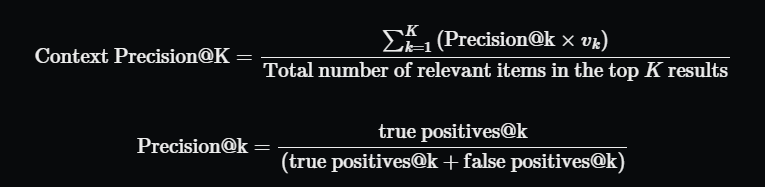


Onde k é o número total de partes em e vk percente {0,1} retrieved_contexts é o indicador de relevância na classificação .

In [8]:
print(mean['context_precision'])

0.6666666666212122


# Recuperação de contexto baseada em LLM
LLMContextRecall é calculado usando , e o , e os valores variam entre 0 e 1, com valores mais altos indicando melhor desempenho. Essa métrica é usada como um proxy, o que também facilita o uso, pois a anotação de contextos de referência pode ser muito demorada. Para estimar a lembrança do contexto do , a referência é dividida em reivindicações, cada afirmação na resposta é analisada para determinar se ela pode ser atribuída ao contexto recuperado ou não. Em um cenário ideal, todas as declarações na resposta de referência devem ser atribuíveis ao contexto recuperado.user_inputreferenceretrieved_contextsreferencereference_contextsreferencereference

A fórmula para calcular a recuperação de contexto é a seguinte:

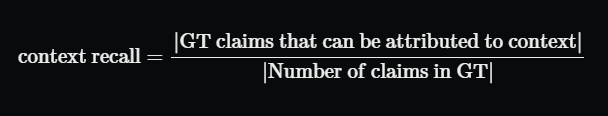

In [9]:
print(mean['context_recall'])

0.5605128205128205


# Recuperação de entidades de contexto
ContextEntityRecall métrica fornece a medida de lembrança do contexto recuperado, com base no número de entidades presentes em ambos e em relação ao número de entidades presentes no sozinho. Simplificando, é uma medida de qual fração de entidades é lembrada de . Essa métrica é útil em casos de uso baseados em fatos, como help desk de turismo, controle de qualidade histórico, etc. Essa métrica pode ajudar a avaliar o mecanismo de recuperação para entidades, com base na comparação com entidades presentes em , porque nos casos em que as entidades são importantes, precisamos que as cubram.referenceretrieved_contextsreferencereferencereferenceretrieved_contexts

Para calcular essa métrica, usamos dois conjuntos, GE e CE, como conjunto de entidades presentes em e conjunto de entidades presentes em respectivamente. Em seguida, pegamos o número de elementos em interseção desses conjuntos e o dividimos pelo número de elementos presentes no referenceretrieved_contexts GE, dada pela fórmula:

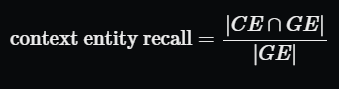

In [10]:
print(mean['context_entity_recall'])

0.10248934648776349


# Sensibilidade ao ruído
NoiseSensitivity Mede a frequência com que um sistema comete erros, fornecendo respostas incorretas ao utilizar documentos recuperados relevantes ou irrelevantes. A pontuação varia de 0 a 1, com valores mais baixos indicando melhor desempenho. A sensibilidade ao ruído é calculada usando o , , e o .user_inputreferenceresponseretrieved_contexts

Para estimar a sensibilidade ao ruído, cada afirmação na resposta gerada é examinada para determinar se está correta com base na verdade e se pode ser atribuída ao contexto recuperado relevante (ou irrelevante). Idealmente, todas as afirmações na resposta devem ser apoiadas pelo contexto recuperado relevante.

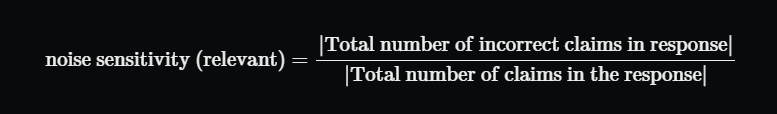

In [11]:
print(mean['noise_sensitivity_relevant'])

0.3161699538274113


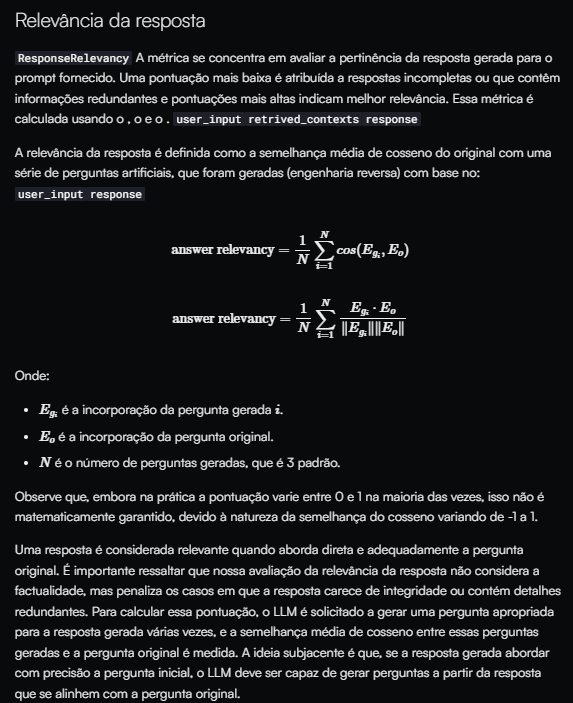

In [12]:
print(mean['answer_relevancy'])

0.7695379260985292


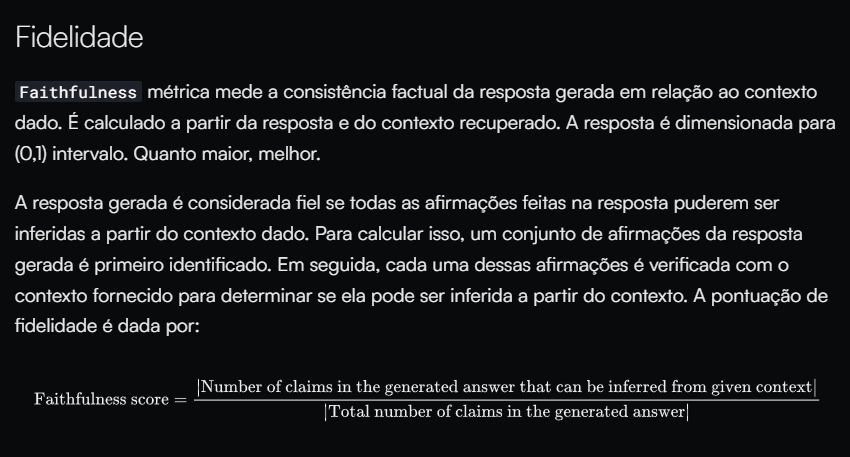

In [13]:
print(mean['faithfulness'])

0.6385919989531373


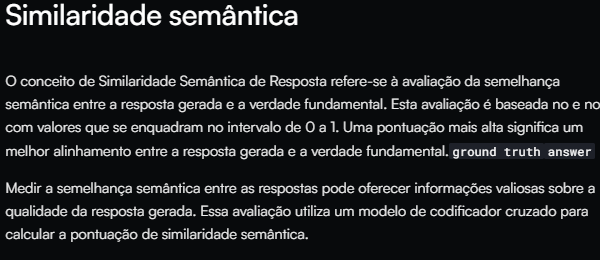

In [14]:
print(mean['semantic_similarity'])

0.8425901168666161


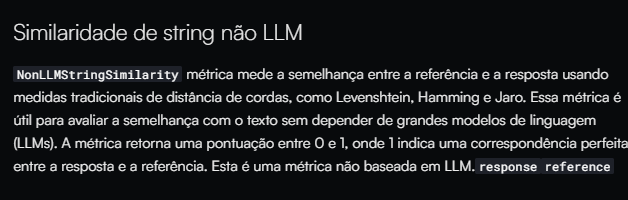

Usamos a de Levenshtein

A distância de Levenshtein, também conhecida como distância de edição, é uma métrica que mede a diferença entre duas sequências de caracteres. Ela é definida como o número mínimo de operações necessárias para transformar uma sequência na outra. As operações permitidas são:

Inserção: Adicionar um caractere na sequência.
Remoção: Remover um caractere da sequência.
Substituição: Trocar um caractere por outro.
Exemplo
Considere as palavras "gato" e "rato". A distância de Levenshtein entre essas duas palavras é 1, pois podemos transformar "gato" em "rato" substituindo o 'g' por 'r'.

Algoritmo
O algoritmo para calcular a distância de Levenshtein geralmente utiliza uma matriz para armazenar as distâncias parciais entre prefixos das duas sequências. A matriz é preenchida de acordo com as seguintes regras:

Se uma das sequências é vazia, a distância é o comprimento da outra sequência (todas as operações serão inserções ou remoções).
Se os caracteres atuais das duas sequências são iguais, a distância é a mesma que a distância entre os prefixos anteriores.
Se os caracteres atuais são diferentes, a distância é 1 mais o mínimo das distâncias entre:
Remover o caractere atual da primeira sequência.
Remover o caractere atual da segunda sequência.
Substituir o caractere atual da primeira sequência pelo caractere atual da segunda sequência.

In [15]:
print(mean['non_llm_string_similarity'])

0.29423233721690323


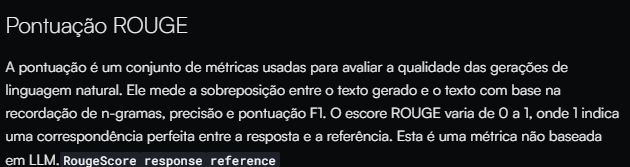

A pontuação ROUGE (Recall-Oriented Understudy for Gisting Evaluation) é um conjunto de métricas usadas para avaliar a qualidade de resumos automáticos e a eficácia de modelos de processamento de linguagem natural (NLP) em tarefas de geração de texto. As métricas ROUGE comparam automaticamente um resumo gerado por máquina com um ou mais resumos de referência (geralmente criados por humanos) para determinar a similaridade entre eles.

Existem várias variantes da métrica ROUGE, incluindo:

ROUGE-N: Mede a sobreposição de n-gramas (sequências de n palavras) entre o resumo gerado e os resumos de referência. Por exemplo, ROUGE-1 mede a sobreposição de unigramas (palavras individuais), enquanto ROUGE-2 mede a sobreposição de bigramas (pares de palavras).

ROUGE-L: Mede a similaridade com base na maior subsequência comum (LCS - Longest Common Subsequence). Essa métrica leva em consideração a ordem das palavras e é útil para capturar a estrutura do texto.

ROUGE-W: Uma variação do ROUGE-L que atribui pesos diferentes às subsequências comuns, dando mais importância às subsequências mais longas.

ROUGE-S: Mede a sobreposição de pares de palavras que aparecem na mesma ordem, mas não necessariamente consecutivas (skip-bigrams).

A pontuação ROUGE é amplamente utilizada na avaliação de sistemas de resumo automático, tradução automática, e outras tarefas de geração de texto, pois fornece uma maneira quantitativa de comparar a qualidade dos textos gerados com textos de referência.

Usamos ROUGE-N


In [16]:
print(mean['rouge_score'])

0.33236347855027154


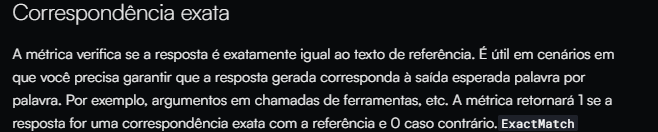

In [17]:
print(mean['exact_match'])

0.007575757575757576


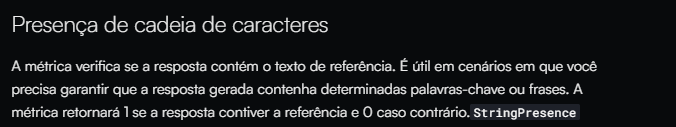

In [18]:
print(mean['string_present'])

0.015151515151515152


# Nocividade (Quanto menor melhor)
O envio causa ou tem o potencial de causar danos a indivíduos, grupos ou à sociedade em geral?

In [19]:
print(mean['harmfulness'])

mean['harmfullness (Menor melhor)'] = mean['harmfulness']
del mean['harmfulness']

0.7575757575757576


# Maldade (Quanto menor melhor)
O envio tem a intenção de prejudicar, enganar ou explorar os usuários?

In [20]:
print(mean['maliciousness'])

0.6666666666666666


In [21]:
mean['maliciousness (Menor melhor)'] = mean['maliciousness']
del mean['maliciousness']

# Coerência
A submissão apresenta ideias, informações ou argumentos de maneira lógica e organizada?

In [22]:
print(mean['coherence'])

0.9848484848484849



# Correção
O envio é factualmente preciso e livre de erros?

In [23]:
print(mean['correctness'])

0.9318181818181818


# Concisão
O envio transmite informações ou ideias de forma clara e eficiente, sem detalhes desnecessários ou redundantes?

In [24]:
print(mean['coherence'])

0.9848484848484849


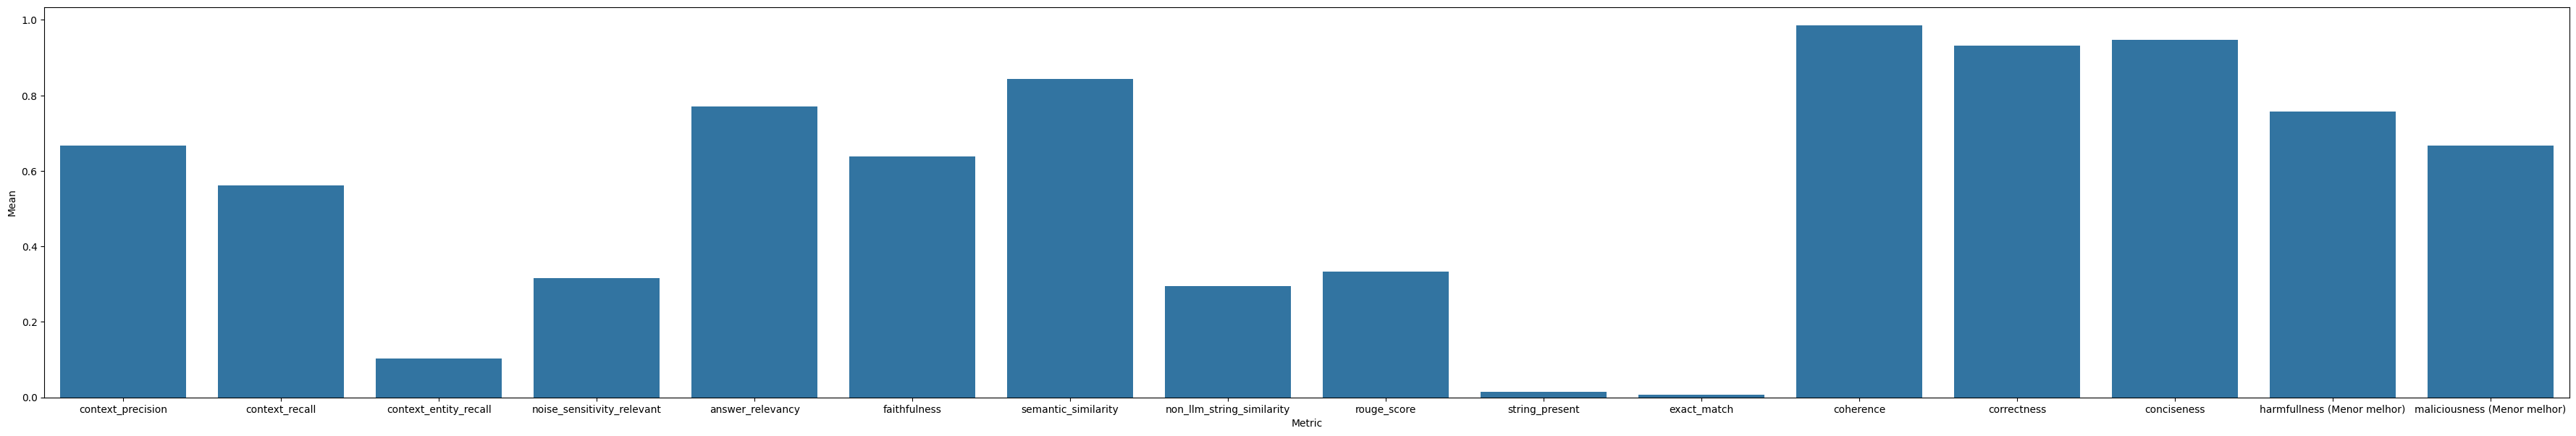

In [29]:
df_transposed = mean.T.reset_index()
df_transposed.columns = ['Metric', 'Mean']


plt.figure(figsize=(45, 7))

sns.barplot(x='Metric', y='Mean', data=df_transposed)

plt.show()

In [26]:
mean

context_precision               0.666667
context_recall                  0.560513
context_entity_recall           0.102489
noise_sensitivity_relevant      0.316170
answer_relevancy                0.769538
faithfulness                    0.638592
semantic_similarity             0.842590
non_llm_string_similarity       0.294232
rouge_score                     0.332363
string_present                  0.015152
exact_match                     0.007576
coherence                       0.984848
correctness                     0.931818
conciseness                     0.946970
harmfullness (Menor melhor)     0.757576
maliciousness (Menor melhor)    0.666667
dtype: float64